# Anomaly Class Exploration

**Key info:**
- `training_batch_with_labels` (Set 0): 2 anomaly sub-classes within label=1
- `first_batch_with_labels` (Set 1): additional anomaly sub-classes
- Combined (Set 0 + Set 1): 4 anomaly sub-classes total
- Both share the same label scheme (0=normal, 1=anomaly), so sub-classes are latent

**Goal:** Compress the sparse feature data into dense representations and visualize to uncover the hidden anomaly sub-clusters.

In [48]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.sparse import csr_matrix
from sklearn.decomposition import PCA, TruncatedSVD
from sklearn.manifold import TSNE
from sklearn.cluster import KMeans, DBSCAN
from sklearn.preprocessing import Normalizer, StandardScaler

# Load data
# Set 0 = training_batch_with_labels (2 anomaly classes)
# Set 1 = first_batch_with_labels
# Set 2 = second_batch_with_labels
f_set0 = np.load("../../ORIGINAL MATS DONT MODIFY/training_batch_with_labels.npz")
f_set1 = np.load("../../ORIGINAL MATS DONT MODIFY/first_batch_with_labels.npz")
f_set2 = np.load("../../ORIGINAL MATS DONT MODIFY/second_batch_with_labels.npz")
f_set0_1 = np.load("../../ORIGINAL MATS DONT MODIFY/Labelled_0_1.npz")
f_set0_1_2 = np.load("../../ORIGINAL MATS DONT MODIFY/Labelled_0_1_2.npz")

print(
    "Set 0 - training_batch (2 anomaly classes) - X:",
    f_set0["X"].shape,
    "y:",
    f_set0["y"].shape,
)
print(
    "Set 1 - first_batch    (another 2 classes) - X:",
    f_set1["X"].shape,
    "y:",
    f_set1["y"].shape,
)
print(
    "Set 2 - second_batch   - X:",
    f_set2["X"].shape,
    "y:",
    f_set2["y"].shape,
)
print("Set 0 and 1 - combined - X:", f_set0_1["X"].shape, "y:", f_set0_1["y"].shape)
print("Set 0, 1 and 2 - combined - X:", f_set0_1_2["X"].shape, "y:", f_set0_1_2["y"].shape)


def _extract_labels(y):
    y = np.asarray(y)
    return y[:, 1] if y.ndim == 2 and y.shape[1] >= 2 else y.ravel()

print("=" * 100)
for name, y_raw in [
    ("Set 0", f_set0["y"]),
    ("Set 1", f_set1["y"]),
    ("Set 2", f_set2["y"]),
    ("Combined (Set 0 + Set 1)", f_set0_1["y"]),
    ("Combined (Set 0 + 1 + 2)", f_set0_1_2["y"]),
]:
    y_lbl = _extract_labels(y_raw)
    anomaly_pct = (y_lbl == 1).mean() * 100
    print(
        f"{name} anomaly percentage: {anomaly_pct:.2f}% ({(y_lbl == 1).sum()}/{len(y_lbl)})"
    )

Set 0 - training_batch (2 anomaly classes) - X: (177346, 3) y: (1100, 2)
Set 1 - first_batch    (another 2 classes) - X: (167493, 3) y: (1100, 2)
Set 2 - second_batch   - X: (134594, 3) y: (860, 2)
Set 0 and 1 - combined - X: (344839, 3) y: (2200, 2)
Set 0, 1 and 2 - combined - X: (479433, 3) y: (3060, 2)
Set 0 anomaly percentage: 9.09% (100/1100)
Set 1 anomaly percentage: 9.09% (100/1100)
Set 2 anomaly percentage: 6.98% (60/860)
Combined (Set 0 + Set 1) anomaly percentage: 9.09% (200/2200)
Combined (Set 0 + 1 + 2) anomaly percentage: 8.50% (260/3060)


## 1. Convert Sparse Triplets to Dense Feature Matrices

Each row in X is `(id, feature_index, value)` — a sparse representation. We convert each ID into a dense 1000-dim vector.

In [49]:
def sparse_to_dense(X_sparse, y_labels):
    """Convert (id, feature_idx, value) triplets to dense matrix + aligned labels."""
    ids = np.unique(X_sparse[:, 0])
    id_to_row = {uid: i for i, uid in enumerate(ids)}
    
    n_samples = len(ids)
    n_features = X_sparse[:, 1].max() + 1
    
    dense = np.zeros((n_samples, n_features), dtype=np.float32)
    for row in X_sparse:
        dense[id_to_row[row[0]], row[1]] = row[2]
    
    # Align labels
    label_dict = dict(y_labels)
    labels = np.array([label_dict[uid] for uid in ids])
    
    return dense, labels, ids

# Convert all sets
X0_dense, y0, ids0 = sparse_to_dense(f_set0['X'], f_set0['y'])
X1_dense, y1, ids1 = sparse_to_dense(f_set1['X'], f_set1['y'])
X2_dense, y2, ids2 = sparse_to_dense(f_set2['X'], f_set2['y'])

print(f"Set 0 (training_batch) dense: {X0_dense.shape}, anomalies: {y0.sum()}/{len(y0)}")
print(f"Set 1 (first_batch)    dense: {X1_dense.shape}, anomalies: {y1.sum()}/{len(y1)}")
print(f"Set 2 (second_batch)   dense: {X2_dense.shape}, anomalies: {y2.sum()}/{len(y2)}")

# Merge everything
X_all = np.concatenate([X0_dense, X1_dense, X2_dense], axis=0)
y_all = np.concatenate([y0, y1, y2], axis=0)
source = np.array(['set0'] * len(y0) + ['set1'] * len(y1) + ['set2'] * len(y2))

print(f"\nCombined dense: {X_all.shape} (All anomaly sub-classes total)")

Set 0 (training_batch) dense: (1100, 1000), anomalies: 100/1100
Set 1 (first_batch)    dense: (1100, 1000), anomalies: 100/1100
Set 2 (second_batch)   dense: (860, 1000), anomalies: 60/860

Combined dense: (3060, 1000) (All anomaly sub-classes total)


## 2. Label Distribution Comparison

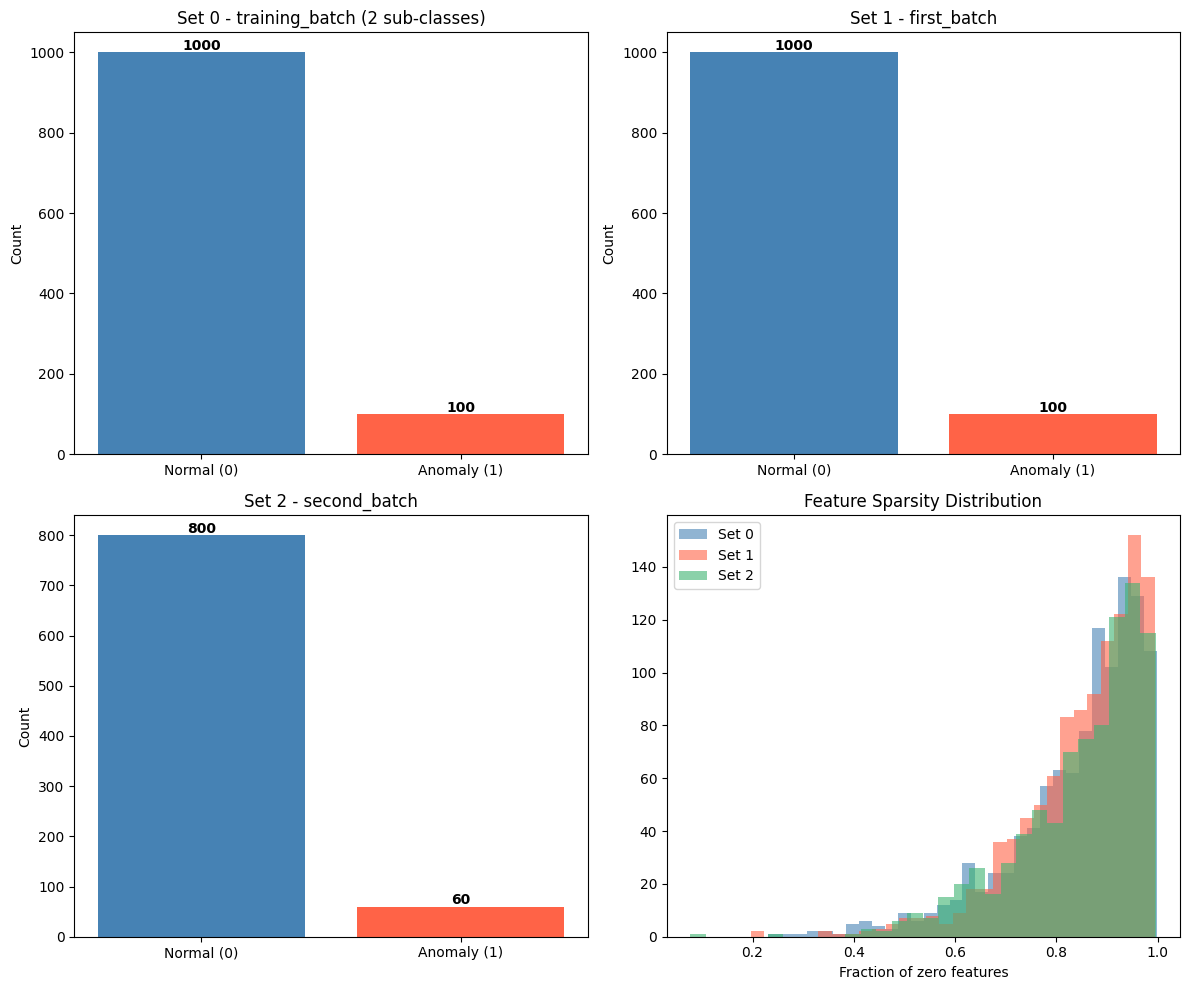

In [50]:
fig, axes = plt.subplots(2, 2, figsize=(12, 10))
axes_flat = axes.flatten()

# Per-set label counts
for ax, (name, labels) in zip(axes_flat[:3], [
    ('Set 0 - training_batch (2 sub-classes)', y0), 
    ('Set 1 - first_batch', y1),
    ('Set 2 - second_batch', y2)
]):
    vals, counts = np.unique(labels, return_counts=True)
    ax.bar(['Normal (0)', 'Anomaly (1)'], counts, color=['steelblue', 'tomato'])
    ax.set_title(name)
    ax.set_ylabel('Count')
    for i, (v, c) in enumerate(zip(vals, counts)):
        ax.text(i, c + 5, str(c), ha='center', fontweight='bold')

# Feature sparsity comparison
sparsity0 = (X0_dense == 0).mean(axis=1)
sparsity1 = (X1_dense == 0).mean(axis=1)
sparsity2 = (X2_dense == 0).mean(axis=1)
axes_flat[3].hist(sparsity0, bins=30, alpha=0.6, label='Set 0', color='steelblue')
axes_flat[3].hist(sparsity1, bins=30, alpha=0.6, label='Set 1', color='tomato')
axes_flat[3].hist(sparsity2, bins=30, alpha=0.6, label='Set 2', color='mediumseagreen')
axes_flat[3].set_title('Feature Sparsity Distribution')
axes_flat[3].set_xlabel('Fraction of zero features')
axes_flat[3].legend()

plt.tight_layout()
plt.show()

## 3. Dimensionality Reduction: PCA

Reduce the 1000-dim feature space to see if anomaly sub-clusters emerge.

Components for 90% variance: 1


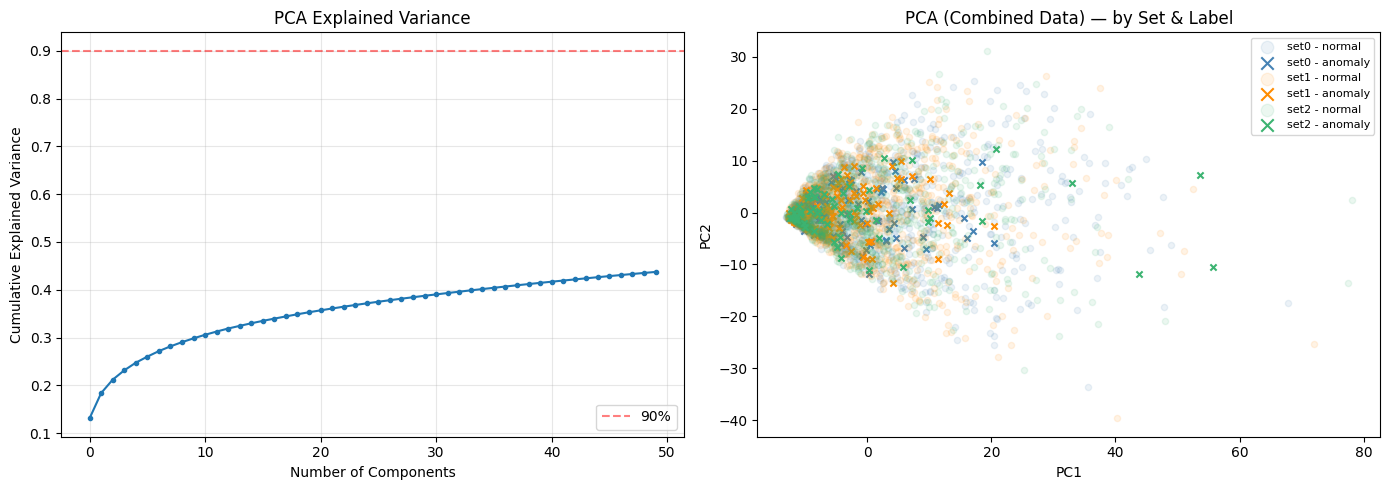

In [51]:
# PCA on all data
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X_all)

pca = PCA(n_components=50)
X_pca = pca.fit_transform(X_scaled)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Explained variance
axes[0].plot(np.cumsum(pca.explained_variance_ratio_), 'o-', markersize=3)
axes[0].set_xlabel('Number of Components')
axes[0].set_ylabel('Cumulative Explained Variance')
axes[0].set_title('PCA Explained Variance')
axes[0].axhline(y=0.9, color='r', linestyle='--', alpha=0.5, label='90%')
axes[0].legend()
axes[0].grid(True, alpha=0.3)

n_90 = np.argmax(np.cumsum(pca.explained_variance_ratio_) >= 0.9) + 1
print(f"Components for 90% variance: {n_90}")

# PCA 2D scatter: normal vs anomaly, colored by source set
colors = {'set0': 'steelblue', 'set1': 'darkorange', 'set2': 'mediumseagreen'}
markers = {0: 'o', 1: 'x'}
for src in ['set0', 'set1', 'set2']:
    for label in [0, 1]:
        mask = (source == src) & (y_all == label)
        lbl = f"{src} - {'anomaly' if label else 'normal'}"
        axes[1].scatter(X_pca[mask, 0], X_pca[mask, 1], 
                       c=colors[src], marker=markers[label],
                       alpha= 1.0 if label == 1 else 0.1, s=20, label=lbl)

axes[1].set_xlabel('PC1')
axes[1].set_ylabel('PC2')
axes[1].set_title('PCA (Combined Data) — by Set & Label')
axes[1].legend(markerscale=2, fontsize=8)

plt.tight_layout()
plt.show()

Running 10 permutations for PCA...


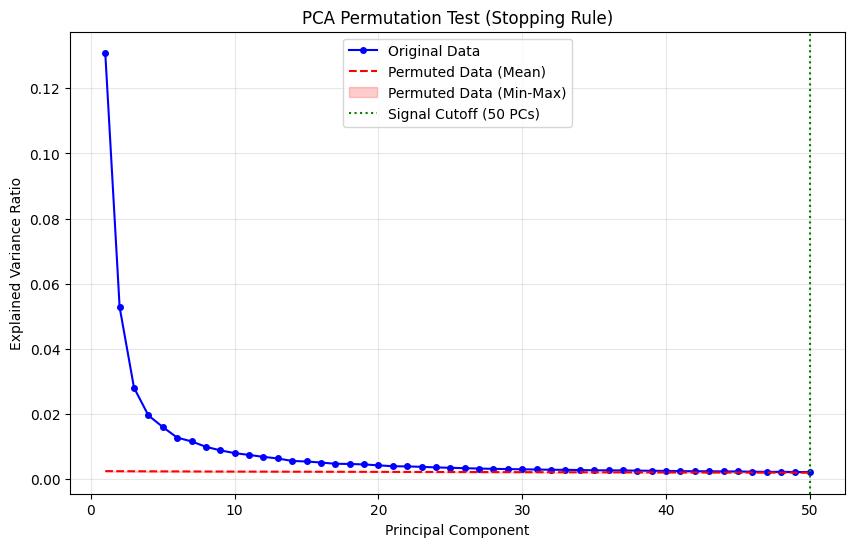

According to the permutation test, the first 50 components contain statistically significant signal.


In [52]:
# --- PCA Permutation Test ---
# Determine how many Principal Components represent true "signal" vs "noise"
# by comparing explained variance of original data against randomly permuted data.

n_permutations = 10
n_components = 50 

original_variance = pca.explained_variance_ratio_
permuted_variances = np.zeros((n_permutations, n_components))

print(f"Running {n_permutations} permutations for PCA...")

for i in range(n_permutations):
    # Shuffle each column independently to destroy correlations
    X_shuffled = X_scaled.copy()
    for col in range(X_shuffled.shape[1]):
        np.random.shuffle(X_shuffled[:, col])
    
    pca_shuffled = PCA(n_components=n_components)
    pca_shuffled.fit(X_shuffled)
    permuted_variances[i, :] = pca_shuffled.explained_variance_ratio_

# Calculate mean and 95th percentile of permuted variances
permuted_mean = np.mean(permuted_variances, axis=0)
permuted_perc = np.percentile(permuted_variances, 5, axis=0)

# The significant components are those where the original variance is greater 
# than the 95th percentile of the permuted variance.
significant_mask = original_variance > permuted_perc
significant_components = np.sum(significant_mask)

plt.figure(figsize=(10, 6))
plt.plot(range(1, n_components + 1), original_variance, 'b-o', markersize=4, label='Original Data')
plt.plot(range(1, n_components + 1), permuted_mean, 'r--', label='Permuted Data (Mean)')
plt.fill_between(range(1, n_components + 1), 
                 np.min(permuted_variances, axis=0), 
                 np.max(permuted_variances, axis=0), 
                 color='red', alpha=0.2, label='Permuted Data (Min-Max)')

plt.axvline(x=significant_components, color='g', linestyle=':', 
            label=f'Signal Cutoff ({significant_components} PCs)')

plt.xlabel('Principal Component')
plt.ylabel('Explained Variance Ratio')
plt.title('PCA Permutation Test (Stopping Rule)')
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

print(f"According to the permutation test, the first {significant_components} components contain statistically significant signal.")

## 4. t-SNE on Anomalies Only

Focus on just the anomaly samples to see if sub-clusters are separable. We expect:
- 2 clusters from Set 0 (training_batch) anomalies
- Additional clusters appearing when Set 1 anomalies are included
- 4 total clusters in the combined data

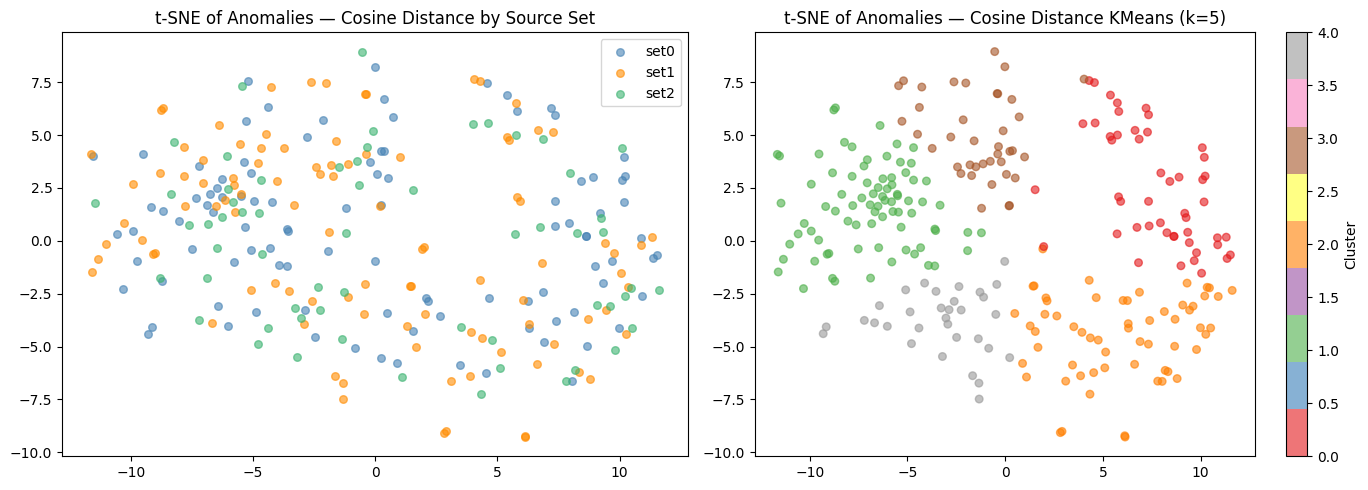


Cluster composition (source set):
  Cluster 0: 22 set0, 15 set1, 12 set2 (total 49)
Anomaly samples: 260, PCA dims used: 50
Unique KMeans clusters found: [0 1 2 3 4]
  Cluster 1: 33 set0, 30 set1, 17 set2 (total 80)
Anomaly samples: 260, PCA dims used: 50
Unique KMeans clusters found: [0 1 2 3 4]
  Cluster 2: 20 set0, 26 set1, 14 set2 (total 60)
Anomaly samples: 260, PCA dims used: 50
Unique KMeans clusters found: [0 1 2 3 4]
  Cluster 3: 15 set0, 17 set1, 7 set2 (total 39)
Anomaly samples: 260, PCA dims used: 50
Unique KMeans clusters found: [0 1 2 3 4]
  Cluster 4: 10 set0, 12 set1, 10 set2 (total 32)
Anomaly samples: 260, PCA dims used: 50
Unique KMeans clusters found: [0 1 2 3 4]


In [53]:
# t-SNE on anomalies only (using PCA-reduced features for speed)
# Keep as a 1D boolean mask even if y_all is shaped (n, 1) or similar
anomaly_mask = np.asarray(y_all).ravel() == 1
X_anom_pca = X_pca[anomaly_mask]
source_anom = source[anomaly_mask]

# Cosine distance is available directly in t-SNE
X_anom_tsne = TSNE(
    n_components=2,
    perplexity=30,
    metric="cosine",
    random_state=42,
    max_iter=1000,
).fit_transform(X_anom_pca)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Color by source set
for src, color in [('set0', 'steelblue'), ('set1', 'darkorange'), ('set2', 'mediumseagreen')]:
    mask = source_anom == src
    axes[0].scatter(X_anom_tsne[mask, 0], X_anom_tsne[mask, 1],
                   c=color, alpha=0.6, s=30, label=f'{src}')
axes[0].set_title('t-SNE of Anomalies — Cosine Distance by Source Set')
axes[0].legend()

# KMeans with k=5 to find sub-clusters
X_anom_tsne_norm = Normalizer().fit_transform(X_anom_tsne)
km = KMeans(n_clusters=5, random_state=42, n_init=10)
cluster_labels = km.fit_predict(X_anom_tsne_norm)

scatter = axes[1].scatter(X_anom_tsne[:, 0], X_anom_tsne[:, 1],
                          c=cluster_labels, cmap='Set1', alpha=0.6, s=30)
axes[1].set_title('t-SNE of Anomalies — Cosine Distance KMeans (k=5)')
plt.colorbar(scatter, ax=axes[1], label='Cluster')

plt.tight_layout()
plt.show()

# Report cluster composition
print("\nCluster composition (source set):")
for c in range(5):
    mask = cluster_labels == c
    n_set0 = (source_anom[mask] == 'set0').sum()
    n_set1 = (source_anom[mask] == 'set1').sum()
    n_set2 = (source_anom[mask] == 'set2').sum()
    print(f"  Cluster {c}: {n_set0} set0, {n_set1} set1, {n_set2} set2 (total {mask.sum()})")
    # Optional sanity checks to avoid common downstream errors
    print(f"Anomaly samples: {X_anom_pca.shape[0]}, PCA dims used: {X_anom_pca.shape[1]}")
    print("Unique KMeans clusters found:", np.unique(cluster_labels))

    # If a later cell expects exactly 5 clusters but fewer are present, warn clearly
    if len(np.unique(cluster_labels)) < 5:
        print("Warning: KMeans returned fewer than 5 effective clusters (some may be empty/merged).")

## 5. t-SNE on All Data (Normal + Anomaly)

Full picture with all samples to see how anomaly sub-types relate to normal samples.

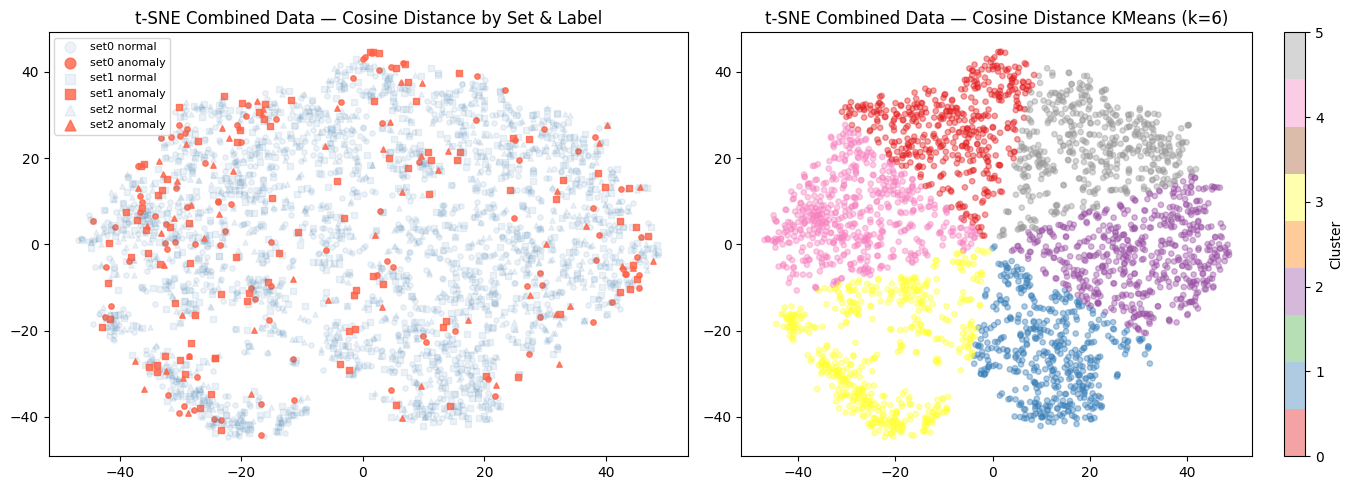

Cluster composition:
  Cluster 0: 405 normal, 45 anomaly (14 set0, 20 set1, 11 set2)
  Cluster 1: 445 normal, 30 anomaly (10 set0, 14 set1, 6 set2)
  Cluster 2: 524 normal, 38 anomaly (18 set0, 11 set1, 9 set2)
  Cluster 3: 475 normal, 49 anomaly (18 set0, 20 set1, 11 set2)
  Cluster 4: 502 normal, 66 anomaly (30 set0, 22 set1, 14 set2)
  Cluster 5: 449 normal, 32 anomaly (10 set0, 13 set1, 9 set2)


In [54]:
# t-SNE on all data
X_all_tsne = TSNE(
    n_components=2,
    perplexity=30,
    metric="cosine",
    random_state=34,
    max_iter=1000,
).fit_transform(X_pca[:, :20])  # Use top 20 PCs for speed

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# By label + source set
for src, marker in [('set0', 'o'), ('set1', 's'), ('set2', '^')]:
    for label, color in [(0, 'steelblue'), (1, 'tomato')]:
        mask = (source == src) & (y_all == label)
        lbl = f"{src} {'anomaly' if label else 'normal'}"
        axes[0].scatter(X_all_tsne[mask, 0], X_all_tsne[mask, 1],
                       c=color, marker=marker, alpha=0.8 if label == 1 else 0.1, s=15, label=lbl)
axes[0].set_title('t-SNE Combined Data — Cosine Distance by Set & Label')
axes[0].legend(markerscale=2, fontsize=8)

# KMeans k=6 on all data
X_all_tsne_norm = Normalizer().fit_transform(X_all_tsne)
km_all = KMeans(n_clusters=6, random_state=42, n_init=4)
clusters_all = km_all.fit_predict(X_all_tsne_norm)
scatter = axes[1].scatter(X_all_tsne[:, 0], X_all_tsne[:, 1],
                          c=clusters_all, cmap='Set1', alpha=0.4, s=15)
axes[1].set_title('t-SNE Combined Data — Cosine Distance KMeans (k=6)')
plt.colorbar(scatter, ax=axes[1], label='Cluster')

plt.tight_layout()
plt.show()

# Cluster composition
print("Cluster composition:")
for c in range(6):
    mask = clusters_all == c
    n_norm = (y_all[mask] == 0).sum()
    n_anom = (y_all[mask] == 1).sum()
    n_set0 = ((source[mask] == 'set0') & (y_all[mask] == 1)).sum()
    n_set1 = ((source[mask] == 'set1') & (y_all[mask] == 1)).sum()
    n_set2 = ((source[mask] == 'set2') & (y_all[mask] == 1)).sum()
    print(f"  Cluster {c}: {n_norm} normal, {n_anom} anomaly ({n_set0} set0, {n_set1} set1, {n_set2} set2)")

## 6. UMAP on Anomalies Only

UMAP preserves more global structure than t-SNE and is faster. Same analysis as section 4 but with UMAP embeddings.

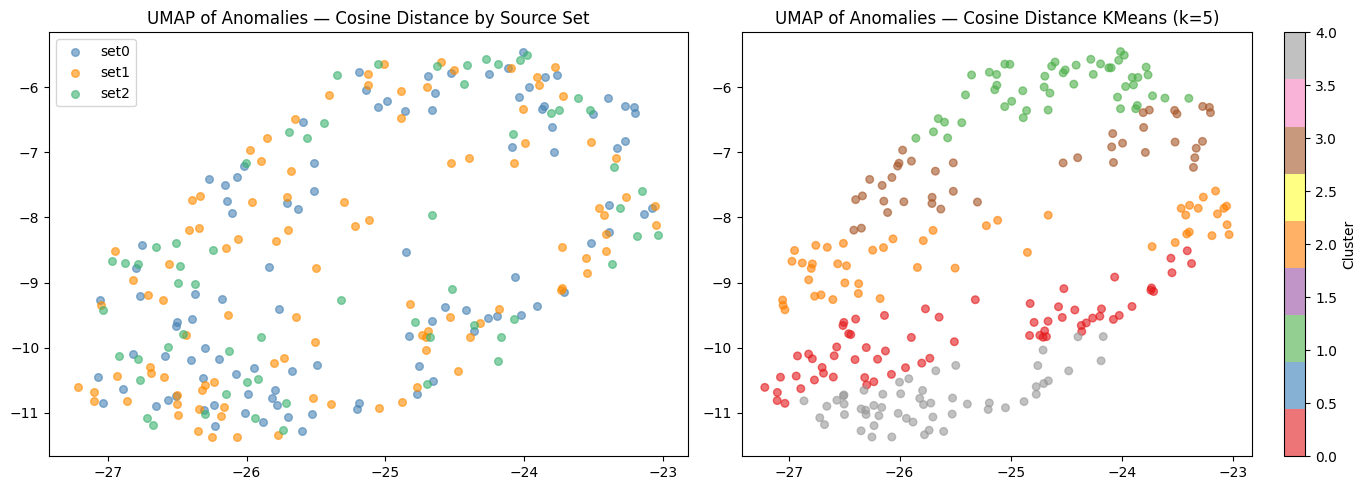


UMAP cluster composition (source set):
  Cluster 0: 26 set0, 27 set1, 14 set2 (total 67)
  Cluster 1: 20 set0, 17 set1, 13 set2 (total 50)
  Cluster 2: 13 set0, 20 set1, 15 set2 (total 48)
  Cluster 3: 19 set0, 16 set1, 6 set2 (total 41)
  Cluster 4: 22 set0, 20 set1, 12 set2 (total 54)


In [55]:
import umap

# UMAP on anomalies only (using PCA-reduced features)
umap_anom = umap.UMAP(n_components=2, n_neighbors=50, min_dist=0.01, metric="cosine")
X_anom_umap = umap_anom.fit_transform(X_anom_pca)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Color by source set
for src, color in [
    ("set0", "steelblue"),
    ("set1", "darkorange"),
    ("set2", "mediumseagreen"),
]:
    mask = source_anom == src
    axes[0].scatter(
        X_anom_umap[mask, 0],
        X_anom_umap[mask, 1],
        c=color,
        alpha=0.6,
        s=30,
        label=f"{src}",
    )
axes[0].set_title("UMAP of Anomalies — Cosine Distance by Source Set")
axes[0].legend()

# KMeans with k=5 to find sub-clusters
X_anom_umap_norm = Normalizer().fit_transform(X_anom_umap)
km_umap = KMeans(n_clusters=5, random_state=42, n_init=10)
cluster_labels_umap = km_umap.fit_predict(X_anom_umap_norm)

scatter = axes[1].scatter(
    X_anom_umap[:, 0],
    X_anom_umap[:, 1],
    c=cluster_labels_umap,
    cmap="Set1",
    alpha=0.6,
    s=30,
)
axes[1].set_title("UMAP of Anomalies — Cosine Distance KMeans (k=5)")
plt.colorbar(scatter, ax=axes[1], label="Cluster")

plt.tight_layout()
plt.show()
# Report cluster composition
print("\nUMAP cluster composition (source set):")
for c in range(5):
    mask = cluster_labels_umap == c
    n_set0 = (source_anom[mask] == "set0").sum()
    n_set1 = (source_anom[mask] == "set1").sum()
    n_set2 = (source_anom[mask] == "set2").sum()
    print(
        f"  Cluster {c}: {n_set0} set0, {n_set1} set1, {n_set2} set2 (total {mask.sum()})"
    )

## 7. UMAP on All Data (Normal + Anomaly)

Full picture with all samples using UMAP to see how anomaly sub-types relate to normal samples.

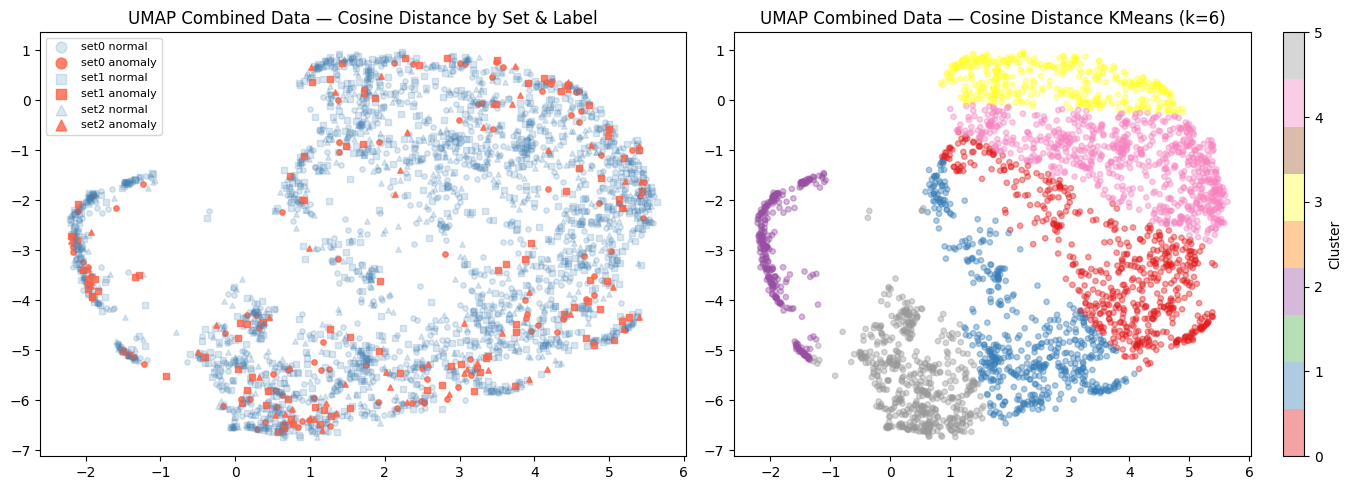

UMAP cluster composition:
  Cluster 0: 528 normal, 44 anomaly (16 set0, 19 set1, 9 set2)
  Cluster 1: 489 normal, 45 anomaly (15 set0, 18 set1, 12 set2)
  Cluster 2: 254 normal, 33 anomaly (12 set0, 14 set1, 7 set2)
  Cluster 3: 377 normal, 43 anomaly (18 set0, 15 set1, 10 set2)
  Cluster 4: 678 normal, 32 anomaly (13 set0, 11 set1, 8 set2)
  Cluster 5: 474 normal, 63 anomaly (26 set0, 23 set1, 14 set2)


In [ ]:
# UMAP on all data
umap_all = umap.UMAP(n_components=2, n_neighbors=50, min_dist=0.02, metric="cosine")
X_all_umap = umap_all.fit_transform(X_pca[:, :20])  # Use top 20 PCs for speed

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# By label + source set
for src, marker in [("set0", "o"), ("set1", "s"), ("set2", "^")]:
    for label, color in [(0, "steelblue"), (1, "tomato")]:
        mask = (source == src) & (y_all == label)
        lbl = f"{src} {'anomaly' if label else 'normal'}"
        axes[0].scatter(
            X_all_umap[mask, 0],
            X_all_umap[mask, 1],
            c=color,
            marker=marker,
            alpha=0.8 if label == 1 else 0.2,
            s=15,
            label=lbl,
        )
axes[0].set_title("UMAP Combined Data — Cosine Distance by Set & Label")
axes[0].legend(markerscale=2, fontsize=8)

# KMeans k=6 on all data
X_all_umap_norm = Normalizer().fit_transform(X_all_umap)
km_all_umap = KMeans(n_clusters=6, random_state=42, n_init=10)
clusters_all_umap = km_all_umap.fit_predict(X_all_umap_norm)
scatter = axes[1].scatter(
    X_all_umap[:, 0],
    X_all_umap[:, 1],
    c=clusters_all_umap,
    cmap="Set1",
    alpha=0.4,
    s=15,
)
axes[1].set_title("UMAP Combined Data — Cosine Distance KMeans (k=6)")
plt.colorbar(scatter, ax=axes[1], label="Cluster")

plt.tight_layout()
plt.show()

# Cluster composition
print("UMAP cluster composition:")
for c in range(6):
    mask = clusters_all_umap == c
    n_norm = (y_all[mask] == 0).sum()
    n_anom = (y_all[mask] == 1).sum()
    n_set0 = ((source[mask] == "set0") & (y_all[mask] == 1)).sum()
    n_set1 = ((source[mask] == "set1") & (y_all[mask] == 1)).sum()
    n_set2 = ((source[mask] == "set2") & (y_all[mask] == 1)).sum()
    print(
        f"  Cluster {c}: {n_norm} normal, {n_anom} anomaly ({n_set0} set0, {n_set1} set1, {n_set2} set2)"
    )

In [57]:
!pip install pacmap

## PaCMAP
TruncatedSVD works directly on sparse data. Also look at which features differ most between normal and anomaly.

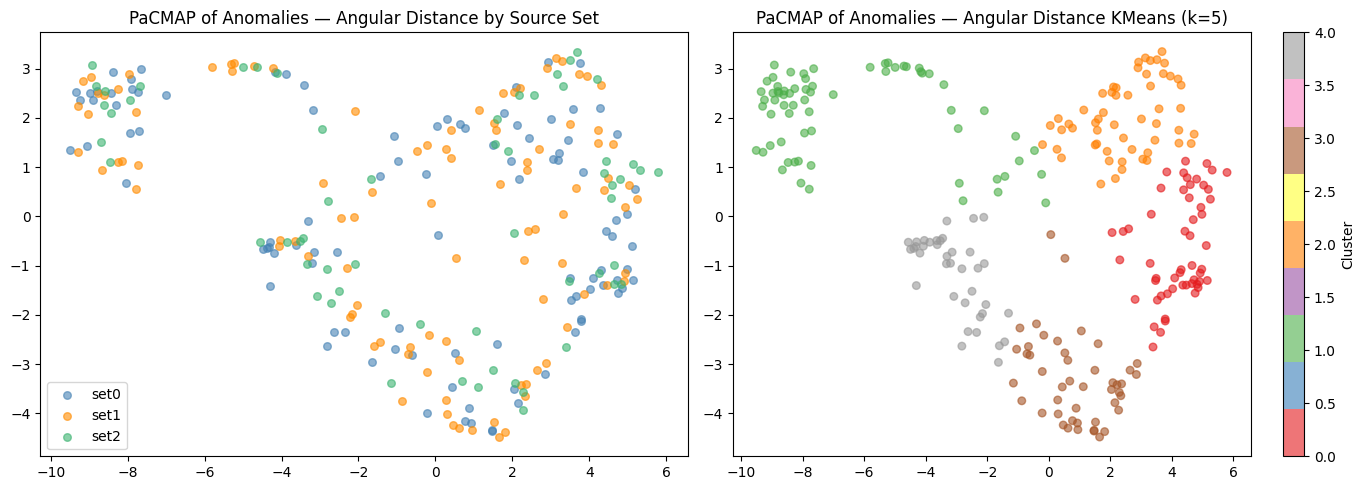


PaCMAP cluster composition (source set):
  Cluster 0: 22 set0, 17 set1, 15 set2 (total 54)
  Cluster 1: 26 set0, 26 set1, 15 set2 (total 67)
  Cluster 2: 21 set0, 24 set1, 10 set2 (total 55)
  Cluster 3: 16 set0, 21 set1, 9 set2 (total 46)
  Cluster 4: 15 set0, 12 set1, 11 set2 (total 38)

PaCMAP (Anomalies): Input dimensions = 50, Output dimensions = 2


In [58]:
import pacmap
import matplotlib.pyplot as plt

# PaCMAP on anomalies only (using PCA-reduced features)
# PaCMAP parameters:
# - n_neighbors: number of neighbors to consider (lower = more local structure)
# - MN_ratio: morning-noon ratio (affects initial/final sampling)
# - FP_ratio: false positive ratio
pacmap_anom = pacmap.PaCMAP(n_components=2, MN_ratio=0.5, FP_ratio=2.0, distance="angular")
X_anom_pacmap = pacmap_anom.fit_transform(X_anom_pca, init="pca")

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Color by source set
for src, color in [
    ("set0", "steelblue"),
    ("set1", "darkorange"),
    ("set2", "mediumseagreen"),
]:
    mask = source_anom == src
    axes[0].scatter(
        X_anom_pacmap[mask, 0],
        X_anom_pacmap[mask, 1],
        c=color,
        alpha=0.6,
        s=30,
        label=f"{src}",
    )
axes[0].set_title("PaCMAP of Anomalies — Angular Distance by Source Set")
axes[0].legend()

# KMeans with k=5 to find sub-clusters
X_anom_pacmap_norm = Normalizer().fit_transform(X_anom_pacmap)
km_pacmap_anom = KMeans(n_clusters=5, random_state=42, n_init=10)
cluster_labels_pacmap_anom = km_pacmap_anom.fit_predict(X_anom_pacmap_norm)

scatter = axes[1].scatter(
    X_anom_pacmap[:, 0],
    X_anom_pacmap[:, 1],
    c=cluster_labels_pacmap_anom,
    cmap="Set1",
    alpha=0.6,
    s=30,
)
axes[1].set_title("PaCMAP of Anomalies — Angular Distance KMeans (k=5)")
plt.colorbar(scatter, ax=axes[1], label="Cluster")

plt.tight_layout()
plt.show()

# Report cluster composition
print("\nPaCMAP cluster composition (source set):")
for c in range(5):
    mask = cluster_labels_pacmap_anom == c
    n_set0 = (source_anom[mask] == "set0").sum()
    n_set1 = (source_anom[mask] == "set1").sum()
    n_set2 = (source_anom[mask] == "set2").sum()
    print(
        f"  Cluster {c}: {n_set0} set0, {n_set1} set1, {n_set2} set2 (total {mask.sum()})"
    )

print(f"\nPaCMAP (Anomalies): Input dimensions = {X_anom_pca.shape[1]}, Output dimensions = {X_anom_pacmap.shape[1]}")

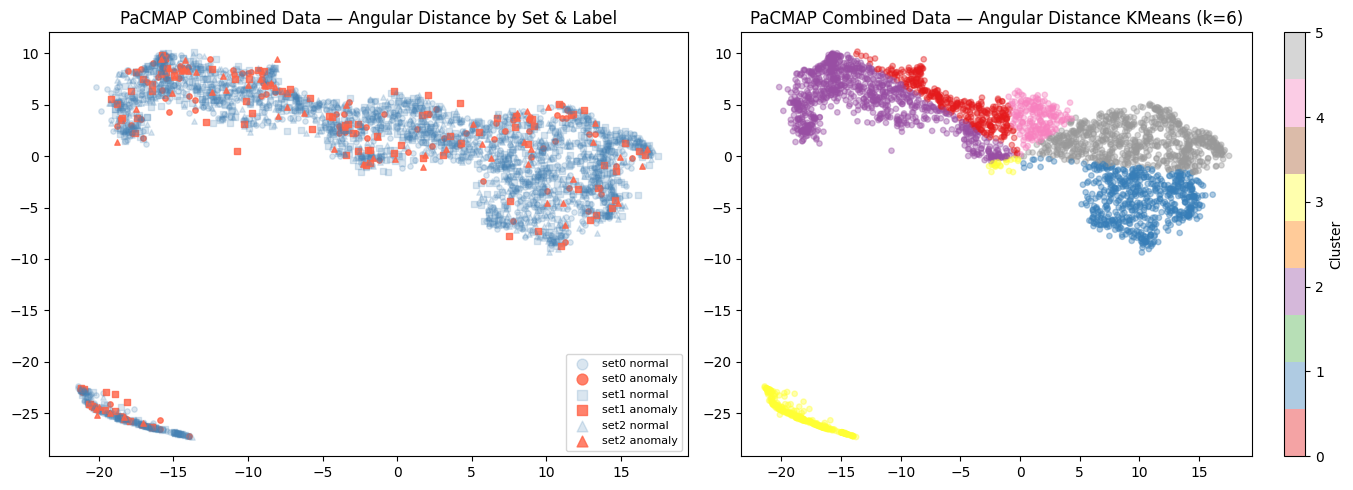

PaCMAP cluster composition:
  Cluster 0: 290 normal, 45 anomaly (20 set0, 16 set1, 9 set2)
  Cluster 1: 588 normal, 25 anomaly (8 set0, 11 set1, 6 set2)
  Cluster 2: 782 normal, 81 anomaly (29 set0, 32 set1, 20 set2)
  Cluster 3: 266 normal, 38 anomaly (14 set0, 16 set1, 8 set2)
  Cluster 4: 198 normal, 9 anomaly (3 set0, 6 set1, 0 set2)
  Cluster 5: 676 normal, 62 anomaly (26 set0, 19 set1, 17 set2)

PaCMAP (Combined Data): Input dimensions = 20 (top 20 PCs from 50 total), Output dimensions = 2


In [59]:
# PaCMAP on all data
pacmap_all = pacmap.PaCMAP(n_components=2, n_neighbors=40, MN_ratio=0.05, FP_ratio=6.0, num_iters=600, distance="angular")
X_all_pacmap = pacmap_all.fit_transform(X_pca[:, :20], init="pca")  # Use top 20 PCs

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# By label + source set
for src, marker in [('set0', 'o'), ('set1', 's'), ('set2', '^')]:
    for label, color in [(0, 'steelblue'), (1, 'tomato')]:
        mask = (source == src) & (y_all == label)
        lbl = f"{src} {'anomaly' if label else 'normal'}"
        axes[0].scatter(X_all_pacmap[mask, 0], X_all_pacmap[mask, 1],
                       c=color, marker=marker, alpha=0.8 if label == 1 else 0.2, s=15, label=lbl)
axes[0].set_title('PaCMAP Combined Data — Angular Distance by Set & Label')
axes[0].legend(markerscale=2, fontsize=8)

# KMeans k=6 on all data
X_all_pacmap_norm = Normalizer().fit_transform(X_all_pacmap)
km_all_pacmap = KMeans(n_clusters=6, random_state=42, n_init=10)
clusters_all_pacmap = km_all_pacmap.fit_predict(X_all_pacmap_norm)
scatter = axes[1].scatter(X_all_pacmap[:, 0], X_all_pacmap[:, 1],
                          c=clusters_all_pacmap, cmap='Set1', alpha=0.4, s=15)
axes[1].set_title('PaCMAP Combined Data — Angular Distance KMeans (k=6)')
plt.colorbar(scatter, ax=axes[1], label='Cluster')

plt.tight_layout()
plt.show()

# Cluster composition
print("PaCMAP cluster composition:")
for c in range(6):
    mask = clusters_all_pacmap == c
    n_norm = (y_all[mask] == 0).sum()
    n_anom = (y_all[mask] == 1).sum()
    n_set0 = ((source[mask] == 'set0') & (y_all[mask] == 1)).sum()
    n_set1 = ((source[mask] == 'set1') & (y_all[mask] == 1)).sum()
    n_set2 = ((source[mask] == 'set2') & (y_all[mask] == 1)).sum()
    print(f"  Cluster {c}: {n_norm} normal, {n_anom} anomaly ({n_set0} set0, {n_set1} set1, {n_set2} set2)")

print(f"\nPaCMAP (Combined Data): Input dimensions = 20 (top 20 PCs from {X_pca.shape[1]} total), Output dimensions = {X_all_pacmap.shape[1]}")

## 8. Independent Component Analysis (ICA)

ICA is another linear decomposition method. Here I run FastICA on the PCA-reduced features to keep the optimization stable, then compare the embeddings for anomalies only and for the full dataset.

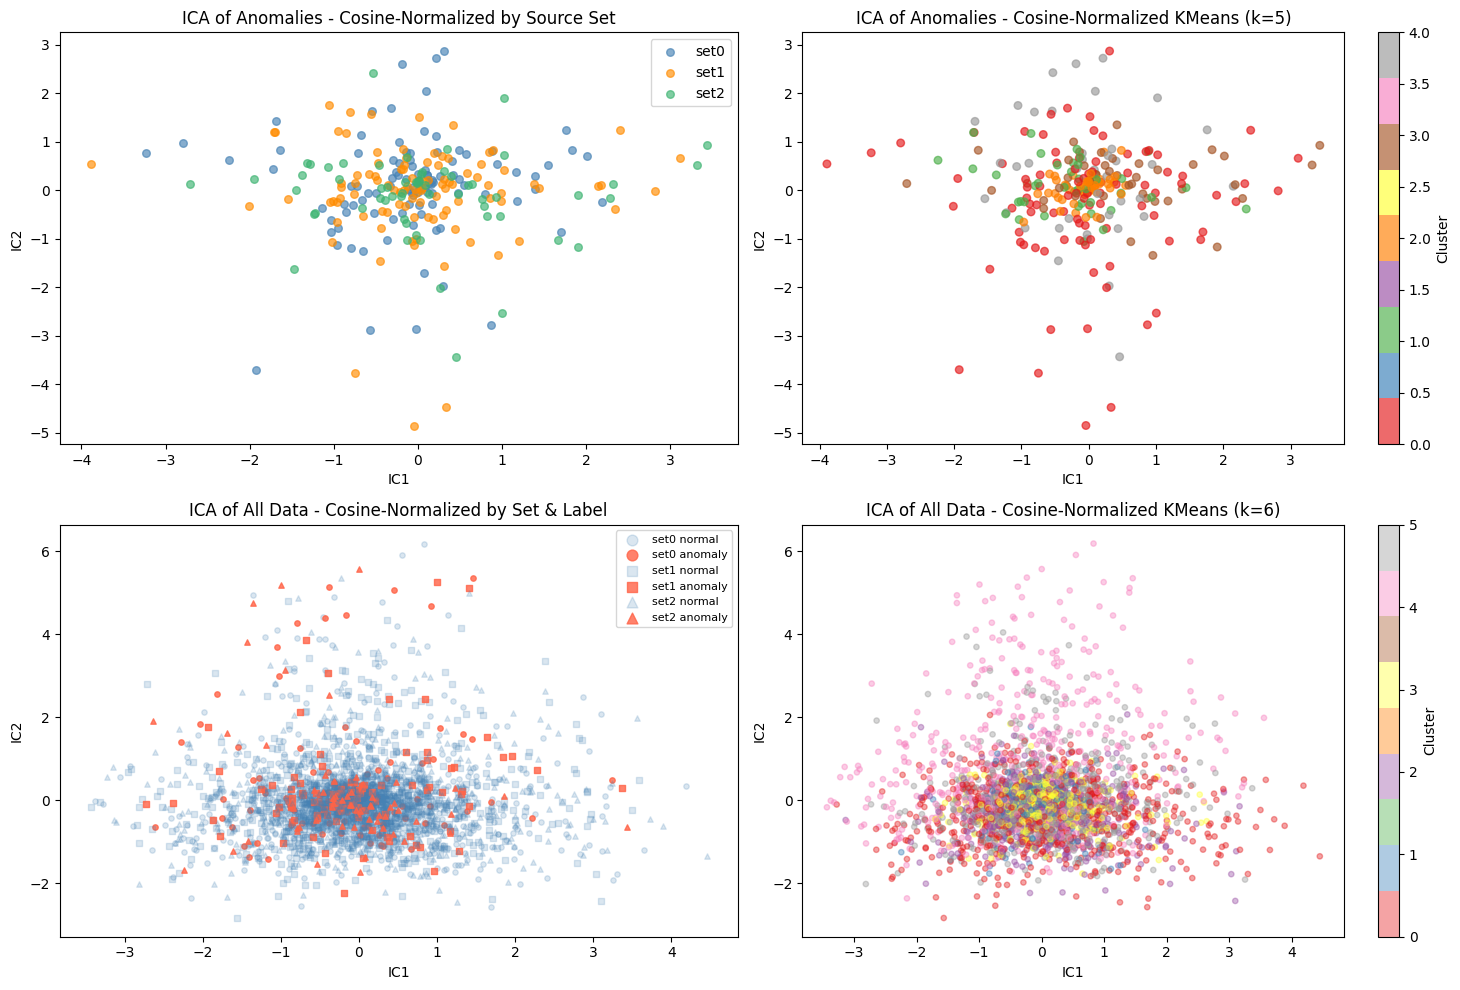

ICA cluster composition (anomalies only):
  Cluster 0: 35 set0, 35 set1, 20 set2 (total 90)
  Cluster 1: 14 set0, 19 set1, 6 set2 (total 39)
  Cluster 2: 18 set0, 19 set1, 9 set2 (total 46)
  Cluster 3: 18 set0, 15 set1, 13 set2 (total 46)
  Cluster 4: 15 set0, 12 set1, 12 set2 (total 39)

ICA cluster composition (all data):
  Cluster 0: 623 normal, 29 anomaly (8 set0, 16 set1, 5 set2)
  Cluster 1: 207 normal, 31 anomaly (12 set0, 14 set1, 5 set2)
  Cluster 2: 437 normal, 26 anomaly (8 set0, 9 set1, 9 set2)
  Cluster 3: 474 normal, 62 anomaly (29 set0, 19 set1, 14 set2)
  Cluster 4: 456 normal, 46 anomaly (20 set0, 16 set1, 10 set2)
  Cluster 5: 603 normal, 66 anomaly (23 set0, 26 set1, 17 set2)

ICA (Anomalies): input dimensions = 20, output dimensions = 20
ICA (All Data): input dimensions = 20, output dimensions = 20


In [60]:
from sklearn.decomposition import FastICA

# ICA on PCA-reduced features for stability and speed
n_ica_components_all = min(20, X_pca.shape[1])
ica_all = FastICA(
    n_components=n_ica_components_all,
    random_state=42,
    whiten="unit-variance",
    max_iter=2000,
    tol=1e-4,
)
X_all_ica = ica_all.fit_transform(Normalizer().fit_transform(X_pca[:, :n_ica_components_all]))

n_ica_components_anom = min(20, X_anom_pca.shape[1])
ica_anom = FastICA(
    n_components=n_ica_components_anom,
    random_state=42,
    whiten="unit-variance",
    max_iter=2000,
    tol=1e-4,
)
X_anom_ica = ica_anom.fit_transform(Normalizer().fit_transform(X_anom_pca[:, :n_ica_components_anom]))

fig, axes = plt.subplots(2, 2, figsize=(15, 10))

# Anomalies only: colored by source set
for src, color in [
    ("set0", "steelblue"),
    ("set1", "darkorange"),
    ("set2", "mediumseagreen"),
]:
    mask = source_anom == src
    axes[0, 0].scatter(
        X_anom_ica[mask, 0],
        X_anom_ica[mask, 1],
        c=color,
        alpha=0.65,
        s=30,
        label=src,
    )
axes[0, 0].set_title("ICA of Anomalies - Cosine-Normalized by Source Set")
axes[0, 0].set_xlabel("IC1")
axes[0, 0].set_ylabel("IC2")
axes[0, 0].legend()

# Anomalies only: KMeans clustering
X_anom_ica_norm = Normalizer().fit_transform(X_anom_ica)
km_ica_anom = KMeans(n_clusters=5, random_state=42, n_init=10)
cluster_labels_ica_anom = km_ica_anom.fit_predict(X_anom_ica_norm)
scatter = axes[0, 1].scatter(
    X_anom_ica[:, 0],
    X_anom_ica[:, 1],
    c=cluster_labels_ica_anom,
    cmap="Set1",
    alpha=0.65,
    s=30,
)
axes[0, 1].set_title("ICA of Anomalies - Cosine-Normalized KMeans (k=5)")
axes[0, 1].set_xlabel("IC1")
axes[0, 1].set_ylabel("IC2")
plt.colorbar(scatter, ax=axes[0, 1], label="Cluster")

# All data: colored by source set and label
for src, marker in [("set0", "o"), ("set1", "s"), ("set2", "^")]:
    for label, color in [(0, "steelblue"), (1, "tomato")]:
        mask = (source == src) & (y_all == label)
        lbl = f"{src} {'anomaly' if label else 'normal'}"
        axes[1, 0].scatter(
            X_all_ica[mask, 0],
            X_all_ica[mask, 1],
            c=color,
            marker=marker,
            alpha=0.8 if label == 1 else 0.2,
            s=15,
            label=lbl,
        )
axes[1, 0].set_title("ICA of All Data - Cosine-Normalized by Set & Label")
axes[1, 0].set_xlabel("IC1")
axes[1, 0].set_ylabel("IC2")
axes[1, 0].legend(markerscale=2, fontsize=8)

# All data: KMeans clustering
X_all_ica_norm = Normalizer().fit_transform(X_all_ica)
km_ica_all = KMeans(n_clusters=6, random_state=42, n_init=10)
clusters_all_ica = km_ica_all.fit_predict(X_all_ica_norm)
scatter = axes[1, 1].scatter(
    X_all_ica[:, 0],
    X_all_ica[:, 1],
    c=clusters_all_ica,
    cmap="Set1",
    alpha=0.4,
    s=15,
)
axes[1, 1].set_title("ICA of All Data - Cosine-Normalized KMeans (k=6)")
axes[1, 1].set_xlabel("IC1")
axes[1, 1].set_ylabel("IC2")
plt.colorbar(scatter, ax=axes[1, 1], label="Cluster")

plt.tight_layout()
plt.show()

print("ICA cluster composition (anomalies only):")
for c in range(5):
    mask = cluster_labels_ica_anom == c
    n_set0 = (source_anom[mask] == "set0").sum()
    n_set1 = (source_anom[mask] == "set1").sum()
    n_set2 = (source_anom[mask] == "set2").sum()
    print(f"  Cluster {c}: {n_set0} set0, {n_set1} set1, {n_set2} set2 (total {mask.sum()})")

print("\nICA cluster composition (all data):")
for c in range(6):
    mask = clusters_all_ica == c
    n_norm = (y_all[mask] == 0).sum()
    n_anom = (y_all[mask] == 1).sum()
    n_set0 = ((source[mask] == "set0") & (y_all[mask] == 1)).sum()
    n_set1 = ((source[mask] == "set1") & (y_all[mask] == 1)).sum()
    n_set2 = ((source[mask] == "set2") & (y_all[mask] == 1)).sum()
    print(f"  Cluster {c}: {n_norm} normal, {n_anom} anomaly ({n_set0} set0, {n_set1} set1, {n_set2} set2)")

print(f"\nICA (Anomalies): input dimensions = {n_ica_components_anom}, output dimensions = {X_anom_ica.shape[1]}")
print(f"ICA (All Data): input dimensions = {n_ica_components_all}, output dimensions = {X_all_ica.shape[1]}")

## 9. Multidimensional Scaling (MDS)

MDS is more expensive than PCA or ICA, so I run it on the same PCA-reduced features and use a capped sample size to keep the notebook responsive while still showing the geometry of the anomaly sub-clusters.

c:\Users\ChunChunMaru\anaconda3\envs\cs421pain\Lib\site-packages\sklearn\manifold\_mds.py:754: FutureWarning: The default value of `init` will change from 'random' to 'classical_mds' in 1.10. To suppress this warning, provide some value of `init`.
  warnings.warn(
c:\Users\ChunChunMaru\anaconda3\envs\cs421pain\Lib\site-packages\sklearn\manifold\_mds.py:771: FutureWarning: The `dissimilarity` parameter is deprecated and will be removed in 1.10. Use `metric` instead.
  warnings.warn(
c:\Users\ChunChunMaru\anaconda3\envs\cs421pain\Lib\site-packages\sklearn\manifold\_mds.py:779: FutureWarning: Use metric_mds=True instead of metric=True. The support for metric={True/False} will be dropped in 1.10.
  warnings.warn(
c:\Users\ChunChunMaru\anaconda3\envs\cs421pain\Lib\site-packages\sklearn\manifold\_mds.py:754: FutureWarning: The default value of `init` will change from 'random' to 'classical_mds' in 1.10. To suppress this warning, provide some value of `init`.
  warnings.warn(
c:\Users\ChunChu

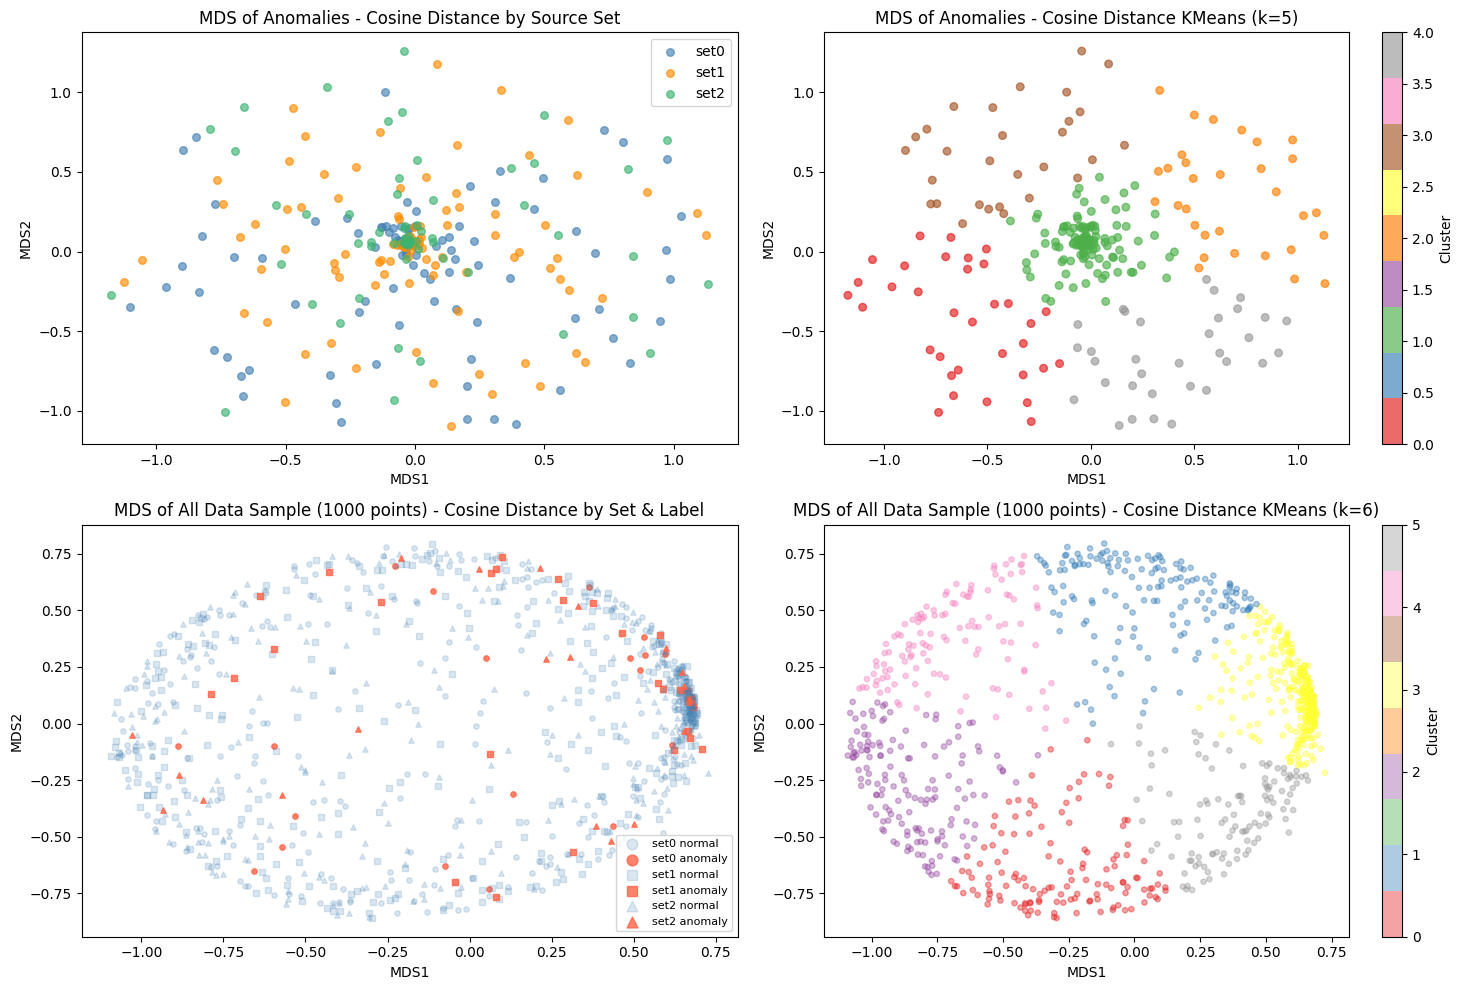

MDS cluster composition (anomalies only):
  Cluster 0: 18 set0, 11 set1, 5 set2 (total 34)
  Cluster 1: 52 set0, 52 set1, 29 set2 (total 133)
  Cluster 2: 12 set0, 10 set1, 9 set2 (total 31)
  Cluster 3: 4 set0, 14 set1, 11 set2 (total 29)
  Cluster 4: 14 set0, 13 set1, 6 set2 (total 33)

MDS cluster composition (all data sample):
  Cluster 0: 126 normal, 7 anomaly (5 set0, 2 set1, 0 set2)
  Cluster 1: 138 normal, 16 anomaly (4 set0, 7 set1, 5 set2)
  Cluster 2: 143 normal, 7 anomaly (2 set0, 0 set1, 5 set2)
  Cluster 3: 295 normal, 33 anomaly (12 set0, 13 set1, 8 set2)
  Cluster 4: 115 normal, 6 anomaly (0 set0, 5 set1, 1 set2)
  Cluster 5: 107 normal, 7 anomaly (2 set0, 2 set1, 3 set2)

MDS (Anomalies): input dimensions = 20, output dimensions = 2
MDS (All Data Sample): input dimensions = 20, output dimensions = 2, sample size = 1000


In [61]:
from sklearn.manifold import MDS
from sklearn.metrics.pairwise import cosine_distances

# MDS on anomalies only using cosine distance on PCA-reduced features
anom_features = X_anom_pca[:, :min(20, X_anom_pca.shape[1])]
mds_anom = MDS(
    n_components=2,
    metric=True,
    random_state=42,
    n_init=1,
    max_iter=300,
    eps=1e-3,
    dissimilarity="precomputed",
)
X_anom_mds = mds_anom.fit_transform(cosine_distances(anom_features))

# MDS on all data: cap the sample size to keep runtime reasonable
mds_all_sample_size = min(1000, X_pca.shape[0])
rng = np.random.default_rng(42)
all_sample_idx = rng.choice(X_pca.shape[0], size=mds_all_sample_size, replace=False)
X_all_mds_input = X_pca[all_sample_idx, :min(20, X_pca.shape[1])]
y_all_mds = y_all[all_sample_idx]
source_all_mds = source[all_sample_idx]

mds_all = MDS(
    n_components=2,
    metric=True,
    random_state=42,
    n_init=1,
    max_iter=300,
    eps=1e-3,
    dissimilarity="precomputed",
)
X_all_mds = mds_all.fit_transform(cosine_distances(X_all_mds_input))

fig, axes = plt.subplots(2, 2, figsize=(15, 10))

# Anomalies only: colored by source set
for src, color in [
    ("set0", "steelblue"),
    ("set1", "darkorange"),
    ("set2", "mediumseagreen"),
]:
    mask = source_anom == src
    axes[0, 0].scatter(
        X_anom_mds[mask, 0],
        X_anom_mds[mask, 1],
        c=color,
        alpha=0.65,
        s=30,
        label=src,
    )
axes[0, 0].set_title("MDS of Anomalies - Cosine Distance by Source Set")
axes[0, 0].set_xlabel("MDS1")
axes[0, 0].set_ylabel("MDS2")
axes[0, 0].legend()

# Anomalies only: KMeans clustering
km_mds_anom = KMeans(n_clusters=5, random_state=42, n_init=10)
cluster_labels_mds_anom = km_mds_anom.fit_predict(X_anom_mds)
scatter = axes[0, 1].scatter(
    X_anom_mds[:, 0],
    X_anom_mds[:, 1],
    c=cluster_labels_mds_anom,
    cmap="Set1",
    alpha=0.65,
    s=30,
)
axes[0, 1].set_title("MDS of Anomalies - Cosine Distance KMeans (k=5)")
axes[0, 1].set_xlabel("MDS1")
axes[0, 1].set_ylabel("MDS2")
plt.colorbar(scatter, ax=axes[0, 1], label="Cluster")

# All data sample: colored by set and label
for src, marker in [("set0", "o"), ("set1", "s"), ("set2", "^")]:
    for label, color in [(0, "steelblue"), (1, "tomato")]:
        mask = (source_all_mds == src) & (y_all_mds == label)
        lbl = f"{src} {'anomaly' if label else 'normal'}"
        axes[1, 0].scatter(
            X_all_mds[mask, 0],
            X_all_mds[mask, 1],
            c=color,
            marker=marker,
            alpha=0.8 if label == 1 else 0.2,
            s=15,
            label=lbl,
        )
axes[1, 0].set_title(f"MDS of All Data Sample ({mds_all_sample_size} points) - Cosine Distance by Set & Label")
axes[1, 0].set_xlabel("MDS1")
axes[1, 0].set_ylabel("MDS2")
axes[1, 0].legend(markerscale=2, fontsize=8)

# All data sample: KMeans clustering
km_mds_all = KMeans(n_clusters=6, random_state=42, n_init=10)
clusters_all_mds = km_mds_all.fit_predict(X_all_mds)
scatter = axes[1, 1].scatter(
    X_all_mds[:, 0],
    X_all_mds[:, 1],
    c=clusters_all_mds,
    cmap="Set1",
    alpha=0.4,
    s=15,
)
axes[1, 1].set_title(f"MDS of All Data Sample ({mds_all_sample_size} points) - Cosine Distance KMeans (k=6)")
axes[1, 1].set_xlabel("MDS1")
axes[1, 1].set_ylabel("MDS2")
plt.colorbar(scatter, ax=axes[1, 1], label="Cluster")

plt.tight_layout()
plt.show()

print("MDS cluster composition (anomalies only):")
for c in range(5):
    mask = cluster_labels_mds_anom == c
    n_set0 = (source_anom[mask] == "set0").sum()
    n_set1 = (source_anom[mask] == "set1").sum()
    n_set2 = (source_anom[mask] == "set2").sum()
    print(f"  Cluster {c}: {n_set0} set0, {n_set1} set1, {n_set2} set2 (total {mask.sum()})")

print("\nMDS cluster composition (all data sample):")
for c in range(6):
    mask = clusters_all_mds == c
    n_norm = (y_all_mds[mask] == 0).sum()
    n_anom = (y_all_mds[mask] == 1).sum()
    n_set0 = ((source_all_mds[mask] == "set0") & (y_all_mds[mask] == 1)).sum()
    n_set1 = ((source_all_mds[mask] == "set1") & (y_all_mds[mask] == 1)).sum()
    n_set2 = ((source_all_mds[mask] == "set2") & (y_all_mds[mask] == 1)).sum()
    print(f"  Cluster {c}: {n_norm} normal, {n_anom} anomaly ({n_set0} set0, {n_set1} set1, {n_set2} set2)")

print(f"\nMDS (Anomalies): input dimensions = {anom_features.shape[1]}, output dimensions = {X_anom_mds.shape[1]}")
print(f"MDS (All Data Sample): input dimensions = {X_all_mds_input.shape[1]}, output dimensions = {X_all_mds.shape[1]}, sample size = {mds_all_sample_size}")